In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
from google.colab import drive
import os
# Mount Google Drive
drive.mount('/content/drive')

# Đường dẫn tới dataset (sửa lại cho đúng với Drive của bạn)
dataset_path = '/content/drive/MyDrive/Waste_Classification_Dataset'

# Check xem path có đúng không
import os
print("Folders:", os.listdir(dataset_path))

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Folders: ['Plastic', 'Metal', 'Miscellaneous', 'Paper']


In [ ]:
# Đếm số ảnh (file có đuôi jpg/png/jpeg)
dataset_path = '/content/drive/MyDrive/Waste_Classification_Dataset'
count = sum([len(files) for r, d, files in os.walk(dataset_path) if any(f.lower().endswith(('.jpg', '.png', '.jpeg')) for f in files)])
print("Tổng số ảnh (bao gồm folder con):", count)


Tổng số ảnh (bao gồm folder con): 16281


Có bao nhiêu loại rác? Tên từng loại?


In [ ]:
import os
from pathlib import Path
import matplotlib.pyplot as plt

# Đường dẫn tới dataset
dataset_path = '/content/drive/MyDrive/Waste_Classification_Dataset'

# Liệt kê các thư mục (mỗi thư mục = 1 class)
classes = os.listdir(dataset_path)
classes = [c for c in classes if os.path.isdir(os.path.join(dataset_path, c))]

print(f"Số lượng classes: {len(classes)}")
print(f"Tên các classes: {classes}")

Số lượng classes: 4
Tên các classes: ['Miscellaneous', 'Plastic', 'Paper', 'Metal']


 Mỗi class có bao nhiêu ảnh ? Kiếm tra imbalance Kiểm tra class imbalance
Biết cần xử lý gì (augmentation nhiều hơn cho class ít ảnh, hoặc dùng class weights)

           Class  Count
1        Plastic   6807
2  Miscellaneous   4424
3          Paper   2767
0          Metal   2283

Tổng số ảnh: 16281


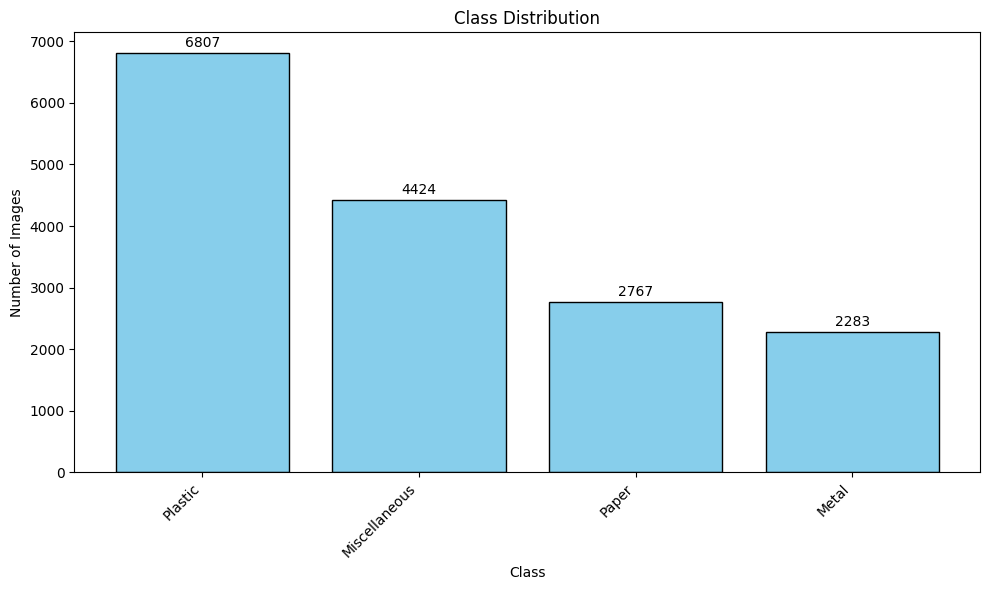

In [ ]:
import os
import pandas as pd
import matplotlib.pyplot as plt

# 🔹 Sửa dòng này: trỏ đến thư mục gốc chứa tất cả class
dataset_path = '/content/drive/MyDrive/Waste_Classification_Dataset'

# Lọc bỏ thư mục ẩn (nếu có, ví dụ .ipynb_checkpoints)
classes = [c for c in os.listdir(dataset_path) if not c.startswith('.')]

# Đếm số ảnh trong mỗi class
class_counts = {}
for class_name in classes:
    class_path = os.path.join(dataset_path, class_name)
    num_images = len([
        f for f in os.listdir(class_path)
        if f.lower().endswith(('.jpg', '.jpeg', '.png'))
    ])
    class_counts[class_name] = num_images

# Sắp xếp và hiển thị
df_counts = pd.DataFrame(list(class_counts.items()), columns=['Class', 'Count'])
df_counts = df_counts.sort_values('Count', ascending=False)
print(df_counts)
print(f"\nTổng số ảnh: {df_counts['Count'].sum()}")

# Visualize
plt.figure(figsize=(10, 6))
plt.bar(df_counts['Class'], df_counts['Count'], color='skyblue', edgecolor='black')
plt.xlabel('Class')
plt.ylabel('Number of Images')
plt.title('Class Distribution')
plt.xticks(rotation=45, ha='right')
for i, v in enumerate(df_counts['Count']):
    plt.text(i, v + 50, str(v), ha='center', va='bottom', fontsize=10)
plt.tight_layout()
plt.savefig('class_distribution.png', dpi=300)
plt.show()


Nhận xét: có mất cân bằng, augmentation cho metal, paper và miscellaneous

In [ ]:
import os

dataset_path = '/content/drive/MyDrive/Waste_Classification_Dataset'

for root, dirs, files in os.walk(dataset_path):
    img_files = [f for f in files if f.lower().endswith(('.jpg', '.png', '.jpeg'))]
    if img_files:
        print(f"{root}: {len(img_files)} ảnh")


/content/drive/MyDrive/Waste_Classification_Dataset/Metal: 2283 ảnh
/content/drive/MyDrive/Waste_Classification_Dataset/Plastic: 6807 ảnh
/content/drive/MyDrive/Waste_Classification_Dataset/Miscellaneous: 4424 ảnh
/content/drive/MyDrive/Waste_Classification_Dataset/Paper: 2767 ảnh


Kích thước ảnh nnao:
-Biết phải resize về size nào (ResNet yêu cầu 224x224)
-Kiểm tra có ảnh quá nhỏ/quá lớn/bị lỗi không
-Hiểu aspect ratio (tỷ lệ width/height)

Width  - Min: 220, Max: 420, Avg: 324
Height - Min: 220, Max: 420, Avg: 315
Aspect Ratio - Min: 1.00, Max: 1.33, Avg: 1.03


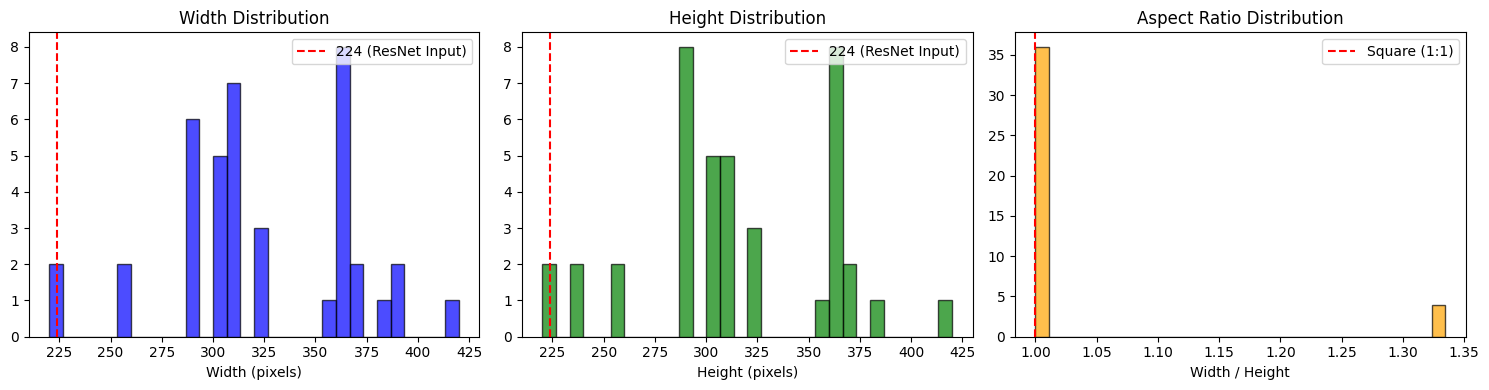

In [ ]:
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
import os

widths, heights, aspects = [], [], []

for class_name in classes:
    class_path = os.path.join(dataset_path, class_name)
    image_files = [
        f for f in os.listdir(class_path)
        if f.lower().endswith(('.jpg', '.jpeg', '.png'))
    ]

    # Lấy tối đa 10 ảnh random mỗi class
    if len(image_files) == 0:
        print(f"⚠️ Class '{class_name}' không có ảnh nào.")
        continue

    sample_files = np.random.choice(image_files, min(10, len(image_files)), replace=False)

    for img_file in sample_files:
        img_path = os.path.join(class_path, img_file)
        try:
            with Image.open(img_path) as img:
                w, h = img.size
                widths.append(w)
                heights.append(h)
                aspects.append(w / h)
        except Exception as e:
            print(f"⚠️ Lỗi đọc ảnh {img_file} ({class_name}): {e}")

# Thống kê
if widths and heights and aspects:
    print(f"Width  - Min: {min(widths)}, Max: {max(widths)}, Avg: {np.mean(widths):.0f}")
    print(f"Height - Min: {min(heights)}, Max: {max(heights)}, Avg: {np.mean(heights):.0f}")
    print(f"Aspect Ratio - Min: {min(aspects):.2f}, Max: {max(aspects):.2f}, Avg: {np.mean(aspects):.2f}")

    # Biểu đồ
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))

    axes[0].hist(widths, bins=30, color='blue', alpha=0.7, edgecolor='black')
    axes[0].set_title('Width Distribution')
    axes[0].set_xlabel('Width (pixels)')
    axes[0].axvline(224, color='red', linestyle='--', label='224 (ResNet Input)')
    axes[0].legend()

    axes[1].hist(heights, bins=30, color='green', alpha=0.7, edgecolor='black')
    axes[1].set_title('Height Distribution')
    axes[1].set_xlabel('Height (pixels)')
    axes[1].axvline(224, color='red', linestyle='--', label='224 (ResNet Input)')
    axes[1].legend()

    axes[2].hist(aspects, bins=30, color='orange', alpha=0.7, edgecolor='black')
    axes[2].set_title('Aspect Ratio Distribution')
    axes[2].set_xlabel('Width / Height')
    axes[2].axvline(1.0, color='red', linestyle='--', label='Square (1:1)')
    axes[2].legend()

    plt.tight_layout()
    plt.savefig('image_size_distribution.png', dpi=300)
    plt.show()
else:
    print("Không có ảnh hợp lệ nào để phân tích.")


Nhận xét :
* Width: Đa số ảnh có độ rộng nằm quanh 320px — khá gần với kích thước chuẩn (224×224)
→ resize xuống 224×224 sẽ không bị méo nhiều hoặc mất chi tiết.
* Height: Kích thước khá đồng đều với chiều rộng → nghĩa là ảnh gần như vuông.
* Width/Height trung bình = 1.03( vì aspect ratio ~1 thì vuông) → hầu hết ảnh gần như vuông→ Không cần crop hay padding quá nhiều.

Visual Inspection

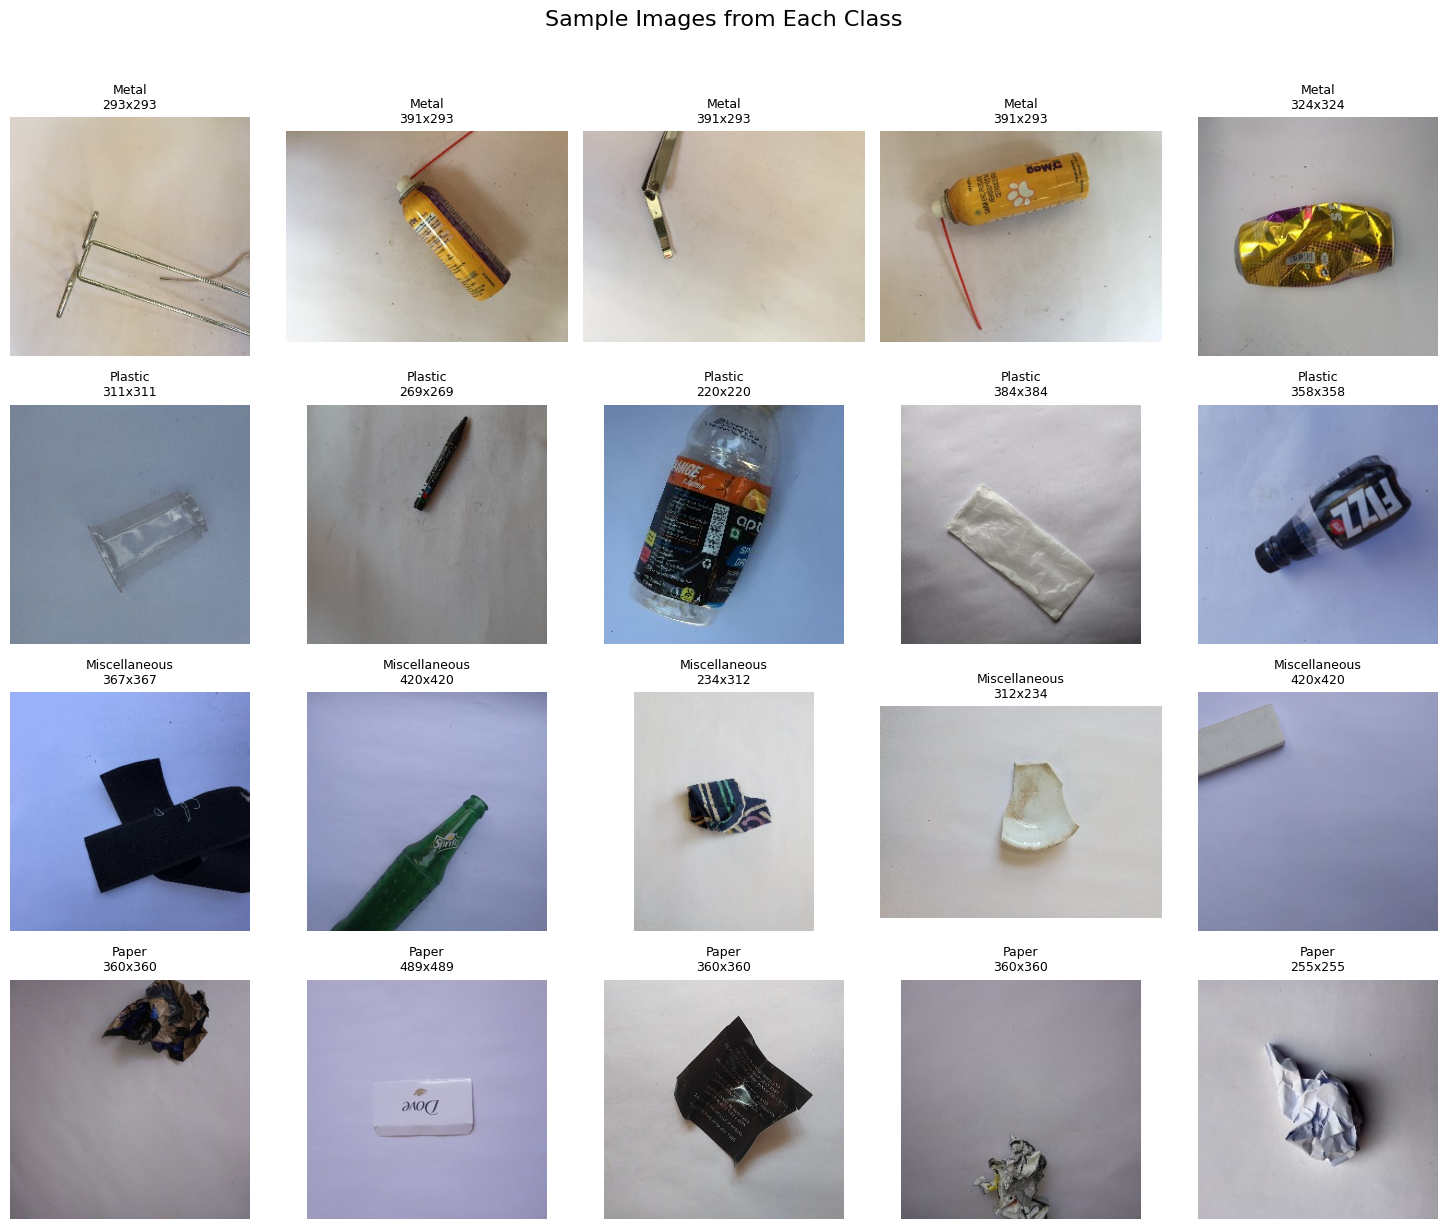

In [ ]:
import random
from PIL import Image
import matplotlib.pyplot as plt
import os

# Hiển thị sample ảnh từ mỗi class
fig, axes = plt.subplots(len(classes), 5, figsize=(15, 3 * len(classes)))

for i, class_name in enumerate(classes):
    class_path = os.path.join(dataset_path, class_name)
    image_files = [f for f in os.listdir(class_path)
                   if f.lower().endswith(('.jpg', '.jpeg', '.png'))]

    # Tránh lỗi nếu class ít hơn 5 ảnh
    if len(image_files) == 0:
        print(f"[⚠️] Class '{class_name}' không có ảnh nào, bỏ qua.")
        continue
    sample_files = random.sample(image_files, min(5, len(image_files)))

    for j, img_file in enumerate(sample_files):
        try:
            img = Image.open(os.path.join(class_path, img_file)).convert("RGB")
            if len(classes) == 1:
                ax = axes[j]
            else:
                ax = axes[i, j]
            ax.imshow(img)
            ax.set_title(f"{class_name}\n{img.size[0]}x{img.size[1]}", fontsize=9)
            ax.axis('off')
        except Exception as e:
            print(f"Lỗi đọc ảnh {img_file}: {e}")

plt.suptitle('Sample Images from Each Class', fontsize=16, y=1.02)
plt.tight_layout()
plt.savefig('sample_images_per_class.png', dpi=300, bbox_inches='tight')
plt.show()


1. Đặc điểm giữa các class

Plastic (nhựa): thường có bề mặt bóng, màu trong suốt hoặc sặc sỡ, dễ nhận thấy các vật như chai nước, túi nylon, bọc nhựa.

Metal (kim loại): có ánh phản chiếu, sáng bạc hoặc vàng, nhiều vật dạng lon, thanh kim loại, ốc vít.

Paper (giấy): thường màu trắng hoặc nhạt, có kết cấu mờ, nhăn, dễ gấp.

Miscellaneous (tạp chất): khá đa dạng, không có đặc trưng hình thái cụ thể, có thể là gốm, vải, cao su...

 2. Background

Hầu hết ảnh có phông nền đồng nhất, màu trắng hoặc xám nhạt.

Độ sáng không đều, một số ảnh có bóng đổ hoặc góc tối hơn

Nền sạch

3. Độ rõ (blur / sáng / tối)

Phần lớn ảnh rõ nét, dễ nhận dạng vật thể.

Có một vài ảnh hơi tối hoặc bóng mạnh, nhất là với vật kim loại hoặc nhựa trong suốt (do phản sáng).

Không có ảnh blur nghiêm trọng trong sample bạn gửi.

 4. Góc chụp

Hầu hết ảnh được chụp từ trên xuống (top-down view), góc gần vuông góc với vật thể.

Một vài ảnh hơi nghiêng nhẹ, nhưng không đáng kể.

-> Giảm nhiễu perspective

Kiểm tra về phân bố màu sắc xem có bị bias lighting k

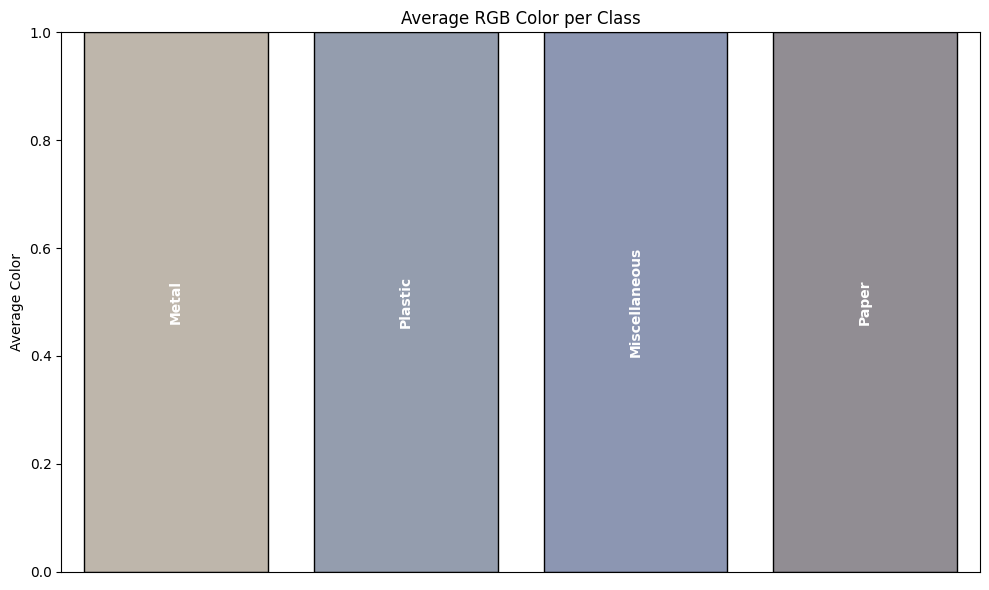


Average RGB values per class:
Metal          : R=189.9, G=182.4, B=170.6
Plastic        : R=148.3, G=157.4, B=173.7
Miscellaneous  : R=139.7, G=150.2, B=178.3
Paper          : R=144.9, G=141.2, B=147.0

Average brightness per class:
Metal          : 181.0
Plastic        : 159.8
Miscellaneous  : 156.1
Paper          : 144.4


In [ ]:
import os
import random
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

# === Tính trung bình RGB cho mỗi class ===
mean_colors = {}

for class_name in classes:
    class_path = os.path.join(dataset_path, class_name)
    image_files = [f for f in os.listdir(class_path)
                   if f.lower().endswith(('.jpg', '.jpeg', '.png'))]

    if len(image_files) == 0:
        print(f"⚠️ Class '{class_name}' không có ảnh nào, bỏ qua.")
        continue

    rgb_values = []
    # Lấy tối đa 50 ảnh ngẫu nhiên
    sample_files = random.sample(image_files, min(50, len(image_files)))

    for img_file in sample_files:
        try:
            img_path = os.path.join(class_path, img_file)
            with Image.open(img_path).convert('RGB') as img:
                img_array = np.array(img)
                mean_rgb = img_array.mean(axis=(0, 1))  # Mean across width & height
                rgb_values.append(mean_rgb)
        except Exception as e:
            print(f"Lỗi đọc ảnh {img_file}: {e}")

    mean_colors[class_name] = np.mean(rgb_values, axis=0)

# === Visualization ===
fig, ax = plt.subplots(figsize=(10, 6))
x_pos = np.arange(len(mean_colors))

for i, class_name in enumerate(mean_colors):
    color = mean_colors[class_name] / 255  # Chuẩn hóa 0–1
    ax.bar(i, 1, color=color, edgecolor='black', width=0.8)
    ax.text(i, 0.5, class_name, ha='center', va='center',
            fontsize=10, rotation=90, color='white', weight='bold')

ax.set_xlim(-0.5, len(mean_colors) - 0.5)
ax.set_ylim(0, 1)
ax.set_xticks([])
ax.set_ylabel('Average Color')
ax.set_title('Average RGB Color per Class')
plt.tight_layout()
plt.savefig('color_distribution_per_class.png', dpi=300)
plt.show()

# === In kết quả RGB và độ sáng trung bình ===
print("\nAverage RGB values per class:")
for class_name, rgb in mean_colors.items():
    print(f"{class_name:15s}: R={rgb[0]:.1f}, G={rgb[1]:.1f}, B={rgb[2]:.1f}")

avg_brightness = {cls: np.mean(rgb) for cls, rgb in mean_colors.items()}
print("\nAverage brightness per class:")
for cls, val in avg_brightness.items():
    print(f"{cls:15s}: {val:.1f}")


Phân tích theo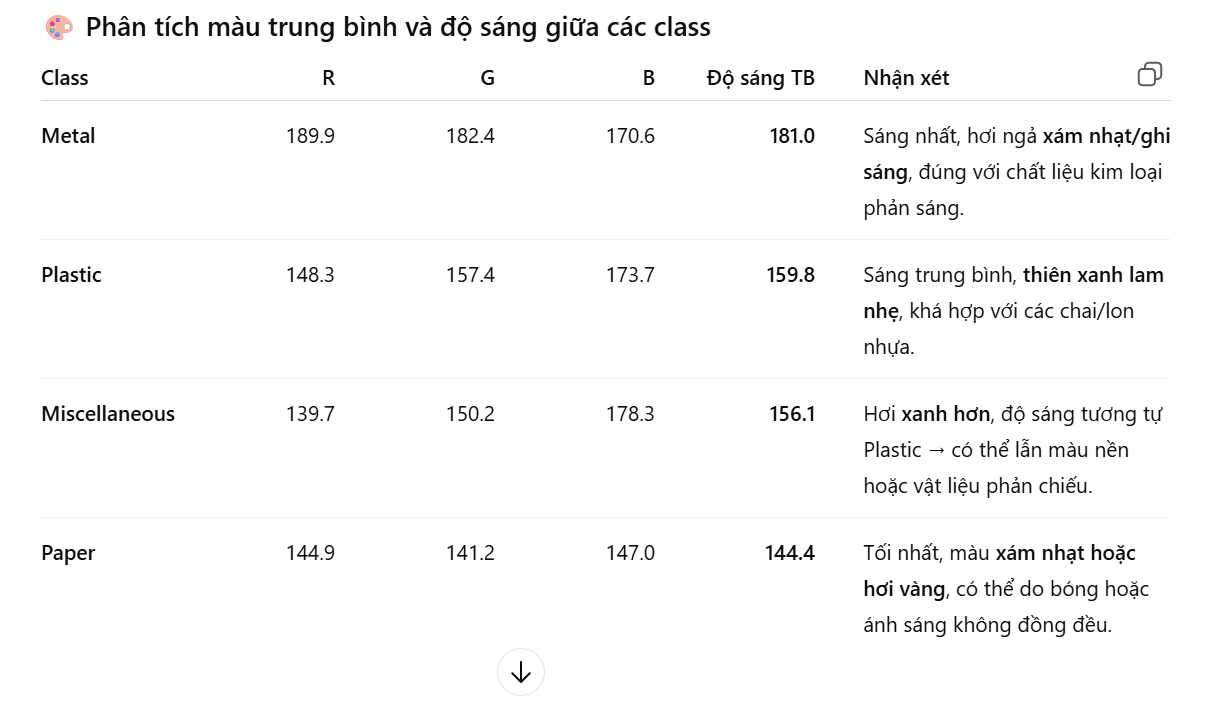


Nhận xét:

* Các class có xu hướng màu và độ sáng khác biệt nhẹ, điều này tốt cho việc phân biệt bằng CNN (vì model có thể học được sắc độ và phản sáng khác nhau).

* Tuy nhiên, Plastic và Miscellaneous khá gần nhau về độ sáng và tone xanh, có thể dẫn đến confusion trong quá trình phân loại → gợi ý nên augment màu (color jitter hoặc histogram equalization) để giảm bias.

Background khá đồng nhất (do giá trị trung bình RGB không quá lệch), chứng tỏ ánh sáng và nền trắng tương đối ổn định.

Paper tối hơn hẳn → nên kiểm tra xem có nhiều bóng hoặc ảnh chụp góc nghiêng khiến giấy trông xám không.

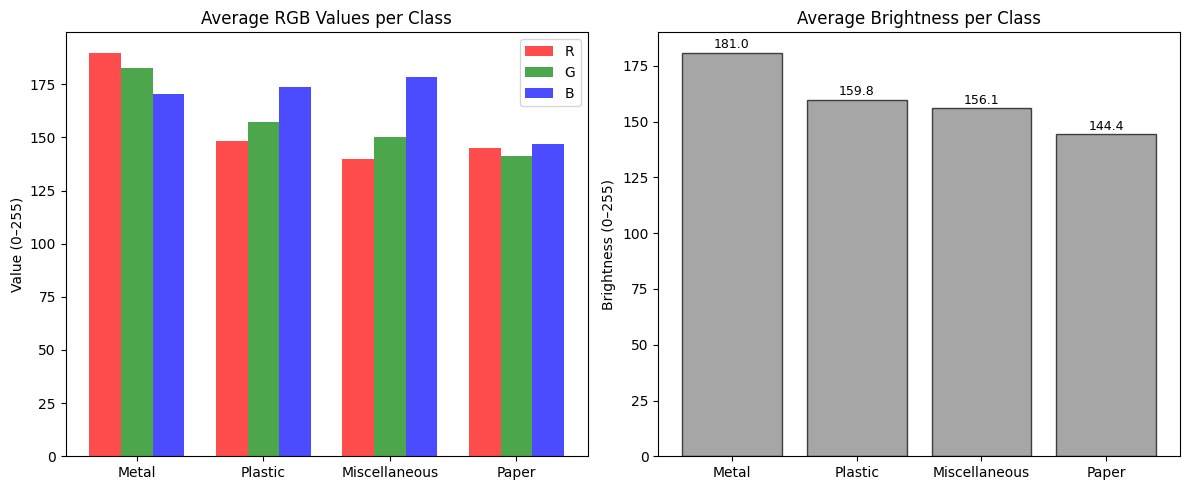

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Dữ liệu lấy từ kết quả bạn có
mean_colors = {
    'Metal': [189.9, 182.4, 170.6],
    'Plastic': [148.3, 157.4, 173.7],
    'Miscellaneous': [139.7, 150.2, 178.3],
    'Paper': [144.9, 141.2, 147.0]
}

brightness = {
    'Metal': 181.0,
    'Plastic': 159.8,
    'Miscellaneous': 156.1,
    'Paper': 144.4
}

# ====== Vẽ biểu đồ RGB ======
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Biểu đồ RGB
classes = list(mean_colors.keys())
r = [mean_colors[c][0] for c in classes]
g = [mean_colors[c][1] for c in classes]
b = [mean_colors[c][2] for c in classes]

x = np.arange(len(classes))
width = 0.25

axes[0].bar(x - width, r, width, color='red', alpha=0.7, label='R')
axes[0].bar(x, g, width, color='green', alpha=0.7, label='G')
axes[0].bar(x + width, b, width, color='blue', alpha=0.7, label='B')

axes[0].set_xticks(x)
axes[0].set_xticklabels(classes)
axes[0].set_title('Average RGB Values per Class')
axes[0].set_ylabel('Value (0–255)')
axes[0].legend()

# ====== Biểu đồ độ sáng ======
brightness_vals = [brightness[c] for c in classes]
axes[1].bar(classes, brightness_vals, color='gray', alpha=0.7, edgecolor='black')

axes[1].set_title('Average Brightness per Class')
axes[1].set_ylabel('Brightness (0–255)')
for i, v in enumerate(brightness_vals):
    axes[1].text(i, v + 2, f'{v:.1f}', ha='center', fontsize=9)

plt.tight_layout()
plt.savefig('rgb_brightness_comparison.png', dpi=300)
plt.show()


Kiểm tra quality issues để phát hiện ảnh corrupt, duplicate, hoặc sai label

In [ ]:
# Check corrupted images
corrupted_images = []
duplicate_sizes = {}

for class_name in classes:
    class_path = os.path.join(dataset_path, class_name)
    image_files = [f for f in os.listdir(class_path)
                   if f.endswith(('.jpg', '.jpeg', '.png'))]

    for img_file in image_files:
        img_path = os.path.join(class_path, img_file)
        try:
            img = Image.open(img_path)
            img.verify()  # Check if corrupted

            # Check duplicate by file size (simple method)
            size = os.path.getsize(img_path)
            if size in duplicate_sizes:
                duplicate_sizes[size].append(img_path)
            else:
                duplicate_sizes[size] = [img_path]

        except Exception as e:
            corrupted_images.append((img_path, str(e)))
            print(f"Corrupted: {img_path} - {e}")

# Report potential duplicates
print(f"\nTotal corrupted images: {len(corrupted_images)}")
potential_duplicates = {k: v for k, v in duplicate_sizes.items() if len(v) > 1}
print(f"Potential duplicate groups: {len(potential_duplicates)}")


Total corrupted images: 0
Potential duplicate groups: 1593


Nhận xét:
* Không có ảnh nào bị lỗi hoặc hỏng (corrupted).
* Có 1,593 nhóm ảnh trùng nhau về kích thước file (bytes).
Tức là trong quá trình kiểm tra, code thấy nhiều file có cùng kích thước y hệt nhau → nghi ngờ là bị trùng ảnh.
* code dưới đã kiểm tra, không có ảnh nào bị trùng

In [ ]:
import hashlib

hash_dict = {}
duplicates = []

for class_name in classes:
    class_path = os.path.join(dataset_path, class_name)
    image_files = [f for f in os.listdir(class_path)
                   if f.lower().endswith(('.jpg', '.jpeg', '.png'))]

    for img_file in image_files:
        img_path = os.path.join(class_path, img_file)
        with open(img_path, 'rb') as f:
            file_hash = hashlib.md5(f.read()).hexdigest()

        if file_hash in hash_dict:
            duplicates.append((img_path, hash_dict[file_hash]))
        else:
            hash_dict[file_hash] = img_path

print(f" Total exact duplicate pairs: {len(duplicates)}")


✅ Total exact duplicate pairs: 0
